# Reliability Engineering Example 2.5

**Name:** Renjia WANG

**Student ID:** 2023040901026

A simplified form of the bathtub curve is based upon the linear and constant hazard/failure rate as follows:

\begin{equation}
\lambda(t)=
\begin{cases}
    c_0 - c_1 t + \lambda, & 0 \le t \le c_0/c_1 \\
    \lambda, & c_0/c_1 \le t \le t_0 \\
    c_2 (t - t_0) + \lambda, & t_0 \le t
\end{cases}.
\tag{1}
\end{equation}

where $c_0$, $c_1$, $c_2$ and $t_0$ are constant to be determined. Find the reliability function.

To concisely calculate the reliability function and the failure probability density function, it is necessary to derive the closed-form solution of reliability function and failure PDF. Denote $H(t)=\int_{0}^{\infty}\lambda(t)dt$ as the hazard function (also called cumulative failure rate function), then the reliability function can be obtained as $R(t)=\exp[-H(t)]$.

\begin{equation}
H(t)=
\begin{cases}
    c_0 t - \frac{c_1}{2} t ^ 2 + \lambda t, & 0 \le t \le c_0/c_1 \\
    \lambda t + \frac{1}{2}\frac{c_0^2}{c_1}, & c_0/c_1 \le t \le t_0 \\
    \lambda t + \frac{c_2}{2} (t - t_0)^2 + \frac{1}{2}\frac{c_0^2}{c_1}, & t_0 \le t
\end{cases}.
\tag{2}
\end{equation}

After that, the reliability function can be calculated via:

\begin{equation}
R(t)=\exp[-H(t)],
\tag{3}
\end{equation}

and the failure probability density function can be derived as:

\begin{equation}
f(t) = R(t) \times \lambda(t).
\tag{4}
\end{equation}

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def calculate_hazard_rate(t, c0, c1, c2, lam, t0):
    t1 = c0 / c1
    if t < 0:
        return 0
    elif t <= t1:
        return c0 - c1 * t + lam
    elif t <= t0:
        return lam
    else:
        return c2 * (t - t0) + lam

def calculate_cumulative_hazard(t, c0, c1, c2, lam, t0):
    t1 = c0 / c1
    H_t1 = (c0 + lam) * t1 - 0.5 * c1 * (t1**2)
    H_t0 = H_t1 + lam * (t0 - t1)

    if t < 0:
        return 0
    elif t <= t1:
        return (c0 + lam) * t - 0.5 * c1 * (t**2)
    elif t <= t0:
        return H_t1 + lam * (t - t1)
    else:
        return H_t0 + lam * (t - t0) + 0.5 * c2 * (t - t0)**2


def generate_reliability_metrics(time_series, params):
    lt_vals = [calculate_hazard_rate(t, **params) for t in time_series]
    H_vals = [calculate_cumulative_hazard(t, **params) for t in time_series]
    
    rt_vals = np.exp(-np.array(H_vals))
    ft_vals = np.array(lt_vals) * rt_vals
    
    return np.array(lt_vals), rt_vals, ft_vals

# --- 3. 可视化层 ---

def plot_on_axes(ax, x, y, ylabel, title, color, linestyle='-'):
    ax.plot(x, y, color=color, linestyle=linestyle, lw=2)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    if 'Reliability' in ylabel: 
        ax.set_ylim(0, 1.1)

def run_visual_experiment(params, title_suffix):
    time_series = np.linspace(0, 15, 500)
    lt, rt, ft = generate_reliability_metrics(time_series, params)
    
    # 2. 创建画布：3行1列
    fig, axes = plt.subplots(1, 3, figsize=(21, 6), sharex=True)
    fig.suptitle(f'Reliability Analysis: {title_suffix}', fontsize=16)

    # 3. 依次绘制三个子图
    # 故障率 Hazard Rate
    plot_on_axes(axes[0], time_series, lt, r'Hazard Rate $\lambda(t)$', 
                 'Hazard Rate', 'blue')
    
    # 可靠度 Reliability
    plot_on_axes(axes[1], time_series, rt, 'Reliability $R(t)$', 
                 'Reliability', 'green', '--')
    
    # 失效密度 PDF
    plot_on_axes(axes[2], time_series, ft, 'Failure PDF $f(t)$', 
                 'Failure PDF', 'red', ':')

    # 4. 细节优化
    axes[2].set_xlabel('Time (t)') # 只有最底下的图显示 X 轴标签
    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # 留出顶部标题空间
    plt.show()

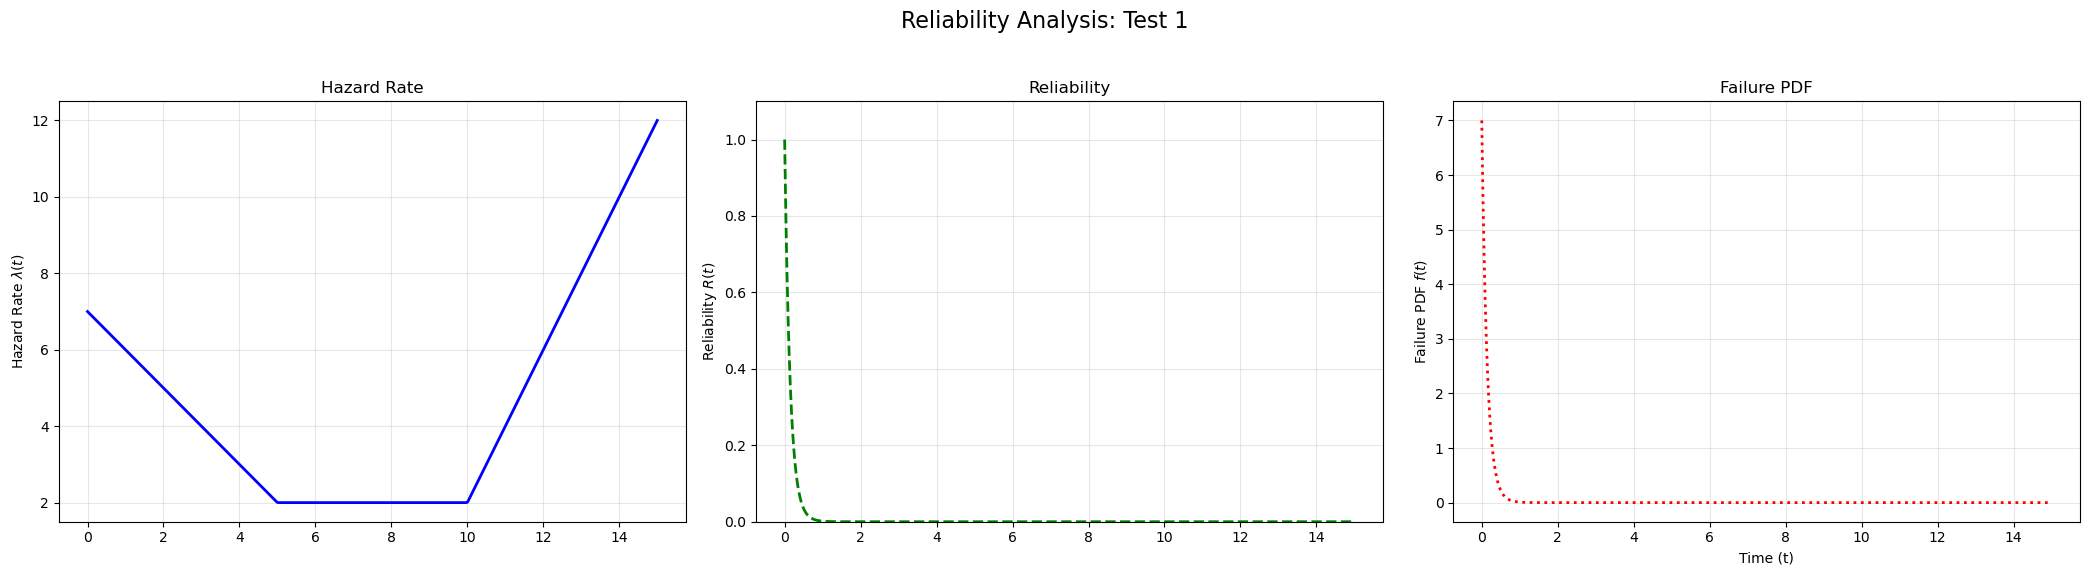

In [2]:
case1 = {'c0': 5, 'c1': 1, 'c2': 2, 'lam': 2, 't0': 10}
run_visual_experiment(case1, "Test 1")

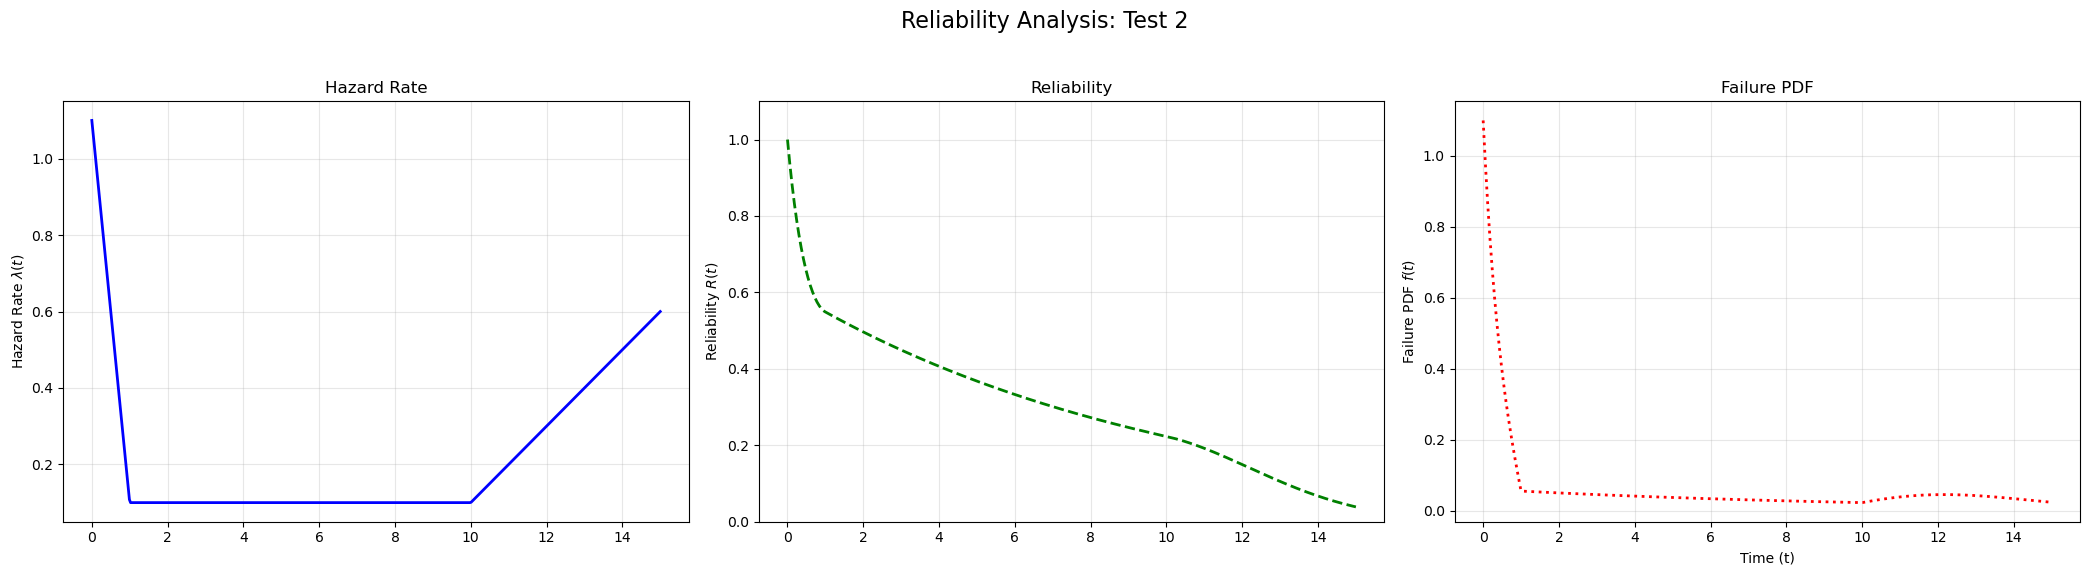

In [16]:
case2 = {'c0': 1, 'c1': 1, 'c2': 0.1, 'lam': 0.1, 't0': 10}
run_visual_experiment(case2, "Test 2")